In [ ]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

# Sklearn
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, ParameterGrid
from sklearn.metrics import (
    f1_score, precision_score, recall_score, accuracy_score,
    classification_report, confusion_matrix
)

# XGBoost
from xgboost import XGBClassifier

warnings.filterwarnings('ignore', category=UserWarning, module='xgboost')
warnings.filterwarnings('ignore', category=FutureWarning)

# ============================================================
# CONSTANTS
# ============================================================
RANDOM_STATE = 42

# Path dataset
DATASET_PATH = r"D:\UNIVERSITAS INDONESIA\Bimbingan 2026\Icha\dataset_fix.xlsx"

# Output directory
OUTPUT_DIR = r"D:\UNIVERSITAS INDONESIA\Bimbingan 2026\Icha\outputFDD_TANPAMULTIVARIAT(2)"
os.makedirs(OUTPUT_DIR, exist_ok=True)

STAGE1_DIR = os.path.join(OUTPUT_DIR, "stage1_fault_detection")
STAGE2_DIR = os.path.join(OUTPUT_DIR, "stage2_fault_diagnosis")
os.makedirs(STAGE1_DIR, exist_ok=True)
os.makedirs(STAGE2_DIR, exist_ok=True)

ALL_FEATURES = [
    # Distribution (8)
    'temp_mean', 'temp_std', 'temp_min', 'temp_max', 'temp_range',
    'temp_skew', 'temp_kurt', 'temp_cv',
    # Rate (4)
    'delta_T_mean', 'delta_T_std', 'delta_T_abs_max', 'delta_T_per_minute_max',
    # Persistence (2)
    'consecutive_identical', '1h_unique_ratio',
    # Statistical (1)
    'temp_zscore_max',
    # Cyclical (4)
    'hour_sin', 'hour_cos', 'month_sin', 'month_cos',
    # Data quality (2)
    'n_gaps', 'max_gap_minute',
]

print(f"Total fitur: {len(ALL_FEATURES)}")
print(f"Output dir : {OUTPUT_DIR}")
print(f"Dataset    : {DATASET_PATH}")

Total fitur: 21
Output dir : D:\UNIVERSITAS INDONESIA\Bimbingan 2026\Icha\outputFDD_TANPAMULTIVARIAT(2)
Dataset    : D:\UNIVERSITAS INDONESIA\Bimbingan 2026\Icha\dataset_fix.xlsx


In [ ]:
# ============================================================
# CELL 2: LOAD DATASET + KOREKSI LABEL (verifikasi manual) + NaN AUDIT
# ============================================================
df_dataset = pd.read_excel(DATASET_PATH)
print(f"Dataset awal: {len(df_dataset)} baris")
print("Distribusi CLASS awal:")
print(df_dataset['CLASS'].value_counts().to_string())

# ------------------------------------------------------------
# 2A. KOREKSI LABEL: ANOMALI -> FAILURE (9 window, hasil verifikasi manual)
#     1 window dari Rule 2 (MEAN_NEGATIVE_FLAKY) + 8 window dari Rule 3 (HAS_NEGATIVE)
#     Window stuck-negatif yang lolos Rule 1 karena T_max tergeser transient.
# ------------------------------------------------------------
LABEL_CORRECTIONS = [
    # (nama_site, WIB_start_time)
    ("PIK",         "2024-03-18 04:00"),  # Rule 2
    ("PIK",         "2024-01-03 21:00"),  # Rule 3
    ("PIK",         "2024-01-03 22:00"),  # Rule 3
    ("Leuwi Dimar", "2025-06-06 00:00"),  # Rule 3
    ("Leuwi Dimar", "2025-06-27 22:00"),  # Rule 3
    ("Leuwi Dimar", "2025-07-01 22:00"),  # Rule 3
    ("Cileles",     "2025-10-23 16:00"),  # Rule 3 (WITH_GAP)
    ("Cileles",     "2025-10-28 12:00"),  # Rule 3 (WITH_GAP)
    ("Cileles",     "2025-10-31 19:00"),  # Rule 3
]

for col in ['nama_site', 'WIB_start_time', 'CLASS']:
    assert col in df_dataset.columns, (
        f"Kolom '{col}' tidak ada. Kolom tersedia: {list(df_dataset.columns)}"
    )

site_key = df_dataset['nama_site'].astype(str).str.strip()
time_key = pd.to_datetime(df_dataset['WIB_start_time'], errors='coerce')

print("\n--- Menerapkan koreksi label ---")
n_fixed = 0
for site, t in LABEL_CORRECTIONS:
    mask = (site_key == site) & (time_key == pd.to_datetime(t))
    found = int(mask.sum())
    if found == 0:
        print(f"  [WARN] TIDAK ketemu: {site} {t}")
        continue
    if found > 1:
        print(f"  [WARN] {found} baris cocok (harusnya 1): {site} {t}")
    before = df_dataset.loc[mask, 'CLASS'].unique().tolist()
    df_dataset.loc[mask, 'CLASS'] = 'FAILURE'
    n_fixed += found
    print(f"  [OK] {site} {t}: {before} -> FAILURE ({found} baris)")

print(f"\nTotal baris terkoreksi: {n_fixed} (target: {len(LABEL_CORRECTIONS)})")
assert n_fixed == len(LABEL_CORRECTIONS), (
    "Jumlah koreksi TIDAK sesuai 9! Cek nama kolom kunci / format WIB_start_time di dataset."
)

print("\nDistribusi CLASS setelah koreksi:")
print(df_dataset['CLASS'].value_counts().to_string())

# ------------------------------------------------------------
# 2B. Cek fitur ada semua
# ------------------------------------------------------------
missing_feats = [f for f in ALL_FEATURES if f not in df_dataset.columns]
assert not missing_feats, f"Fitur tidak ada di dataset: {missing_feats}"

# Snapshot distribusi SEBELUM drop NaN (untuk plot distribusi kelas)
df_dataset_predrop = df_dataset.copy()

# ------------------------------------------------------------
# 2C. NaN audit + drop
# ------------------------------------------------------------
print("\n--- NaN audit ---")
nan_per_col = df_dataset[ALL_FEATURES].isna().sum().sort_values(ascending=False)
nan_per_col = nan_per_col[nan_per_col > 0]
if len(nan_per_col) == 0:
    print("Tidak ada NaN di fitur ML")
else:
    print("Fitur yang punya NaN:")
    print(nan_per_col.to_string())

nan_mask = df_dataset[ALL_FEATURES].isna().any(axis=1)
print(f"\nBaris dengan NaN: {nan_mask.sum()} ({nan_mask.sum()/len(df_dataset)*100:.2f}%)")
if nan_mask.sum() > 0:
    print("Breakdown per kelas yang akan di-drop:")
    print(df_dataset[nan_mask]['CLASS'].value_counts().to_string())

df_dataset = df_dataset[~nan_mask].reset_index(drop=True)
print(f"\nSetelah drop NaN: {len(df_dataset)} baris")
print("Distribusi akhir:")
print(df_dataset['CLASS'].value_counts().to_string())

Dataset awal: 68288 baris
Distribusi CLASS awal:
CLASS
NORMAL        34144
COMM_FAULT    24984
FAILURE        8318
ANOMALI         842

--- Menerapkan koreksi label ---
  [OK] PIK 2024-03-18 04:00: ['ANOMALI'] -> FAILURE (1 baris)
  [OK] PIK 2024-01-03 21:00: ['ANOMALI'] -> FAILURE (1 baris)
  [OK] PIK 2024-01-03 22:00: ['ANOMALI'] -> FAILURE (1 baris)
  [OK] Leuwi Dimar 2025-06-06 00:00: ['ANOMALI'] -> FAILURE (1 baris)
  [OK] Leuwi Dimar 2025-06-27 22:00: ['ANOMALI'] -> FAILURE (1 baris)
  [OK] Leuwi Dimar 2025-07-01 22:00: ['ANOMALI'] -> FAILURE (1 baris)
  [OK] Cileles 2025-10-23 16:00: ['ANOMALI'] -> FAILURE (1 baris)
  [OK] Cileles 2025-10-28 12:00: ['ANOMALI'] -> FAILURE (1 baris)
  [OK] Cileles 2025-10-31 19:00: ['ANOMALI'] -> FAILURE (1 baris)

Total baris terkoreksi: 9 (target: 9)

Distribusi CLASS setelah koreksi:
CLASS
NORMAL        34144
COMM_FAULT    24984
FAILURE        8327
ANOMALI         833

--- NaN audit ---
Fitur yang punya NaN:
temp_kurt          322
temp_skew    

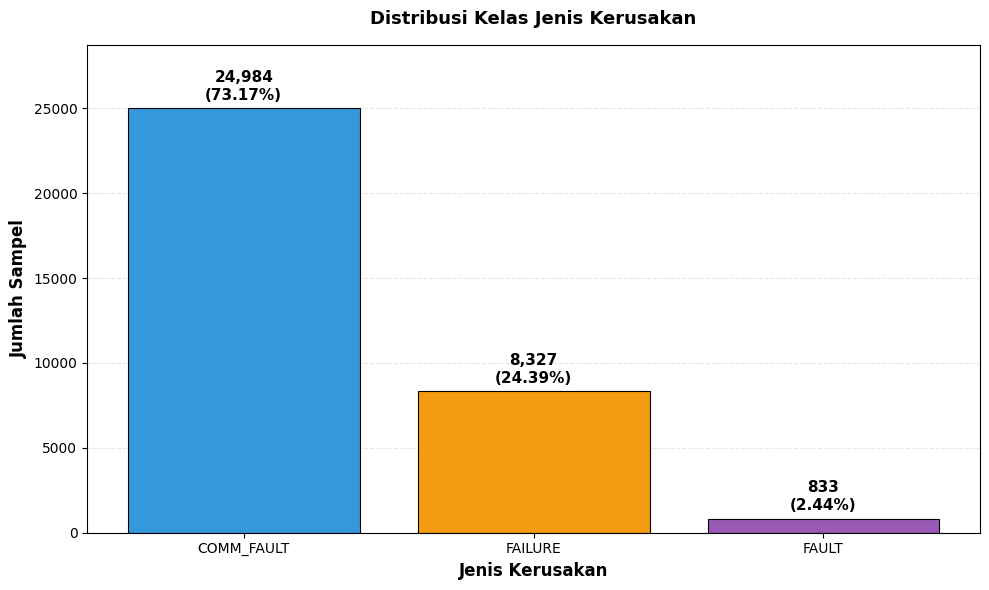

 Distribusi Kelas Fault Type
Kelas               Jumlah        %
--------------------------------------------------
COMM_FAULT          24,984   73.17%
FAILURE              8,327   24.39%
FAULT                  833    2.44%
--------------------------------------------------
TOTAL               34,144  100.00%


In [71]:
# ============================================================
# CELL 2b: PLOT DISTRIBUSI KELAS JENIS KERUSAKAN (setelah koreksi label)
# ============================================================
# Pakai df_dataset_predrop: SUDAH dikoreksi label, TAPI SEBELUM drop NaN.
# Jadi jumlah yang tampil = total sampel per kelas sebelum baris NaN dibuang.

class_order    = ['COMM_FAULT', 'FAILURE', 'ANOMALI']   # nama di kolom CLASS
display_labels = ['COMM_FAULT', 'FAILURE', 'FAULT']     # nama tampilan di grafik
colors         = ['#3498db', '#f39c12', '#9b59b6']

counts = [int(df_dataset_predrop['CLASS'].value_counts().get(c, 0)) for c in class_order]
total  = sum(counts)

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.bar(display_labels, counts, color=colors, edgecolor='black', linewidth=0.8)

for bar, val in zip(bars, counts):
    pct = val / total * 100 if total else 0
    ax.text(bar.get_x() + bar.get_width()/2, val + total * 0.01,
            f'{val:,}\n({pct:.2f}%)', ha='center', va='bottom',
            fontsize=11, fontweight='bold')

ax.set_xlabel('Jenis Kerusakan', fontsize=12, fontweight='bold')
ax.set_ylabel('Jumlah Sampel', fontsize=12, fontweight='bold')
ax.set_title('Distribusi Kelas Jenis Kerusakan', fontsize=13, fontweight='bold', pad=15)
ax.grid(axis='y', alpha=0.3, linestyle='--')
ax.set_axisbelow(True)
ax.set_ylim(0, max(counts) * 1.15 if counts else 1)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "class_distribution_fault_type.png"),
            dpi=150, bbox_inches='tight')
plt.show()

print("=" * 50)
print(" Distribusi Kelas Fault Type")
print("=" * 50)
print(f"{'Kelas':<15} {'Jumlah':>10} {'%':>8}")
print("-" * 50)
for c_display, val in zip(display_labels, counts):
    pct = val / total * 100 if total else 0
    print(f"{c_display:<15} {val:>10,} {pct:>7.2f}%")
print("-" * 50)
print(f"{'TOTAL':<15} {total:>10,} {100:>7.2f}%")

In [61]:
# ============================================================
# CELL 3: STAGE 2 SETUP — split 70:15:15 + scaling
# ============================================================
df_stage2 = df_dataset[df_dataset['CLASS'] != 'NORMAL'].copy().reset_index(drop=True)
print(f"Dataset Stage 2 (ABNORMAL only): {len(df_stage2)}")
print(df_stage2['CLASS'].value_counts().to_string())

class_mapping_s2 = {'ANOMALI': 0, 'FAILURE': 1, 'COMM_FAULT': 2}
class_inverse_s2 = {v: k for k, v in class_mapping_s2.items()}
LABELS_S2 = ['ANOMALI', 'FAILURE', 'COMM_FAULT']

X_full_s2 = df_stage2[ALL_FEATURES].copy()
y_full_s2 = df_stage2['CLASS'].map(class_mapping_s2)

X_train_s2, X_temp_s2, y_train_s2, y_temp_s2 = train_test_split(
    X_full_s2, y_full_s2,
    test_size=0.30, random_state=RANDOM_STATE, stratify=y_full_s2
)
X_val_s2, X_test_s2, y_val_s2, y_test_s2 = train_test_split(
    X_temp_s2, y_temp_s2,
    test_size=0.50, random_state=RANDOM_STATE, stratify=y_temp_s2
)

print("\n=== Stage 2 Split ===")
print(f"Train      : {len(X_train_s2)} -> {dict(y_train_s2.map(class_inverse_s2).value_counts())}")
print(f"Validation : {len(X_val_s2)} -> {dict(y_val_s2.map(class_inverse_s2).value_counts())}")
print(f"Test       : {len(X_test_s2)} -> {dict(y_test_s2.map(class_inverse_s2).value_counts())}")

scaler_s2 = StandardScaler()
X_train_s2_scaled = pd.DataFrame(scaler_s2.fit_transform(X_train_s2),
                                 columns=X_train_s2.columns, index=X_train_s2.index)
X_val_s2_scaled = pd.DataFrame(scaler_s2.transform(X_val_s2),
                               columns=X_val_s2.columns, index=X_val_s2.index)
X_test_s2_scaled = pd.DataFrame(scaler_s2.transform(X_test_s2),
                                columns=X_test_s2.columns, index=X_test_s2.index)

assert X_train_s2_scaled.isna().sum().sum() == 0
assert X_val_s2_scaled.isna().sum().sum() == 0
assert X_test_s2_scaled.isna().sum().sum() == 0
print("\n[OK] Tidak ada NaN di scaled Stage 2")

y_splits_s2 = {'train': y_train_s2.values, 'val': y_val_s2.values, 'test': y_test_s2.values}

Dataset Stage 2 (ABNORMAL only): 33820
CLASS
COMM_FAULT    24669
FAILURE        8318
ANOMALI         833

=== Stage 2 Split ===
Train      : 23674 -> {'COMM_FAULT': 17268, 'FAILURE': 5823, 'ANOMALI': 583}
Validation : 5073 -> {'COMM_FAULT': 3701, 'FAILURE': 1247, 'ANOMALI': 125}
Test       : 5073 -> {'COMM_FAULT': 3700, 'FAILURE': 1248, 'ANOMALI': 125}

[OK] Tidak ada NaN di scaled Stage 2


In [62]:
# ============================================================
# CELL 4: HELPER — confusion matrix per split
# ============================================================
def plot_cm_separate(y_true, y_pred, labels, split_name, model_name,
                     save_dir, save_prefix, cmap='Blues', figsize=(7, 6)):
    cm = confusion_matrix(y_true, y_pred, labels=list(range(len(labels))))
    fig, ax = plt.subplots(figsize=figsize)
    sns.heatmap(cm, annot=True, fmt='d', cmap=cmap, cbar=True,
                xticklabels=labels, yticklabels=labels, ax=ax,
                annot_kws={'size': 12})
    ax.set_xlabel('Predicted', fontsize=11)
    ax.set_ylabel('Actual', fontsize=11)
    ax.set_title(f'{model_name} — Confusion Matrix ({split_name.capitalize()})',
                 fontsize=12, fontweight='bold')
    plt.tight_layout()
    out = os.path.join(save_dir, f"cm_{save_prefix}_{split_name}.png")
    plt.savefig(out, dpi=150, bbox_inches='tight')
    plt.show()
    return cm

--- Feature Importance RF ---
               feature  importance
              temp_min    0.189322
             temp_mean    0.184957
              temp_max    0.149816
       1h_unique_ratio    0.114173
               temp_cv    0.067672
 consecutive_identical    0.066177
              temp_std    0.059462
            temp_range    0.052382
           delta_T_std    0.038064
        max_gap_minute    0.027436
       delta_T_abs_max    0.018752
delta_T_per_minute_max    0.015430
                n_gaps    0.011551
          delta_T_mean    0.002247
             temp_skew    0.001123
             temp_kurt    0.000866
       temp_zscore_max    0.000314
             month_sin    0.000087
              hour_cos    0.000081
             month_cos    0.000063
              hour_sin    0.000026


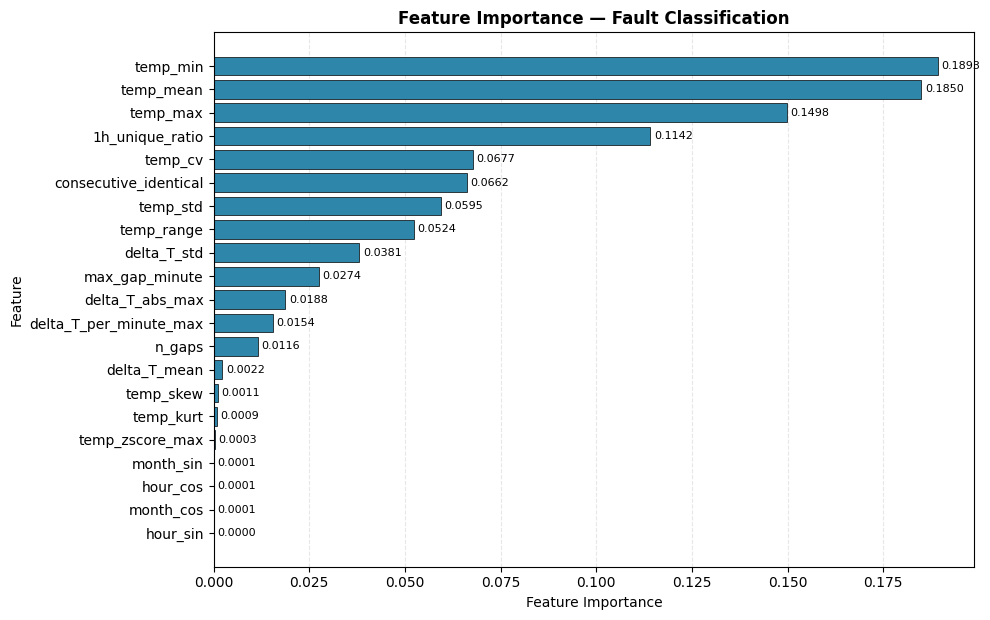

In [63]:
# ============================================================
# CELL 5: STAGE 2 — RANDOM FOREST feature importance
# ============================================================
print("--- Feature Importance RF ---")
rf_proxy_s2 = RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE, n_jobs=-1)
rf_proxy_s2.fit(X_train_s2_scaled, y_train_s2)

importance_rf_s2 = pd.DataFrame({
    'feature': X_train_s2_scaled.columns,
    'importance': rf_proxy_s2.feature_importances_
}).sort_values('importance', ascending=False).reset_index(drop=True)
print(importance_rf_s2.to_string(index=False))
importance_rf_s2.to_excel(os.path.join(STAGE2_DIR, "feature_importance_rf.xlsx"), index=False)

fig, ax = plt.subplots(figsize=(10, max(6, len(importance_rf_s2) * 0.3)))
ax.barh(importance_rf_s2['feature'][::-1], importance_rf_s2['importance'][::-1],
        color='#2E86AB', edgecolor='black', linewidth=0.5)
for i, val in enumerate(importance_rf_s2['importance'][::-1]):
    ax.text(val + max(importance_rf_s2['importance']) * 0.005, i, f'{val:.4f}',
            va='center', fontsize=8)
ax.set_xlabel('Feature Importance'); ax.set_ylabel('Feature')
ax.set_title('Feature Importance — Fault Classification', fontsize=12, fontweight='bold')
ax.grid(axis='x', alpha=0.3, linestyle='--'); ax.set_axisbelow(True)
plt.tight_layout()
plt.savefig(os.path.join(STAGE2_DIR, "feature_importance_rf.png"), dpi=150, bbox_inches='tight')
plt.show()

In [64]:
# ============================================================
# CELL 6: TUNING RANDOM FOREST
# ============================================================
N_VALUES_S2 = [7, 14, len(ALL_FEATURES)]
print(f"N values: {N_VALUES_S2}")

RF_GRID = {
    'n_estimators':      [50, 100],
    'max_depth':         [3, 5, 7],
    'min_samples_split': [10, 20],
    'min_samples_leaf':  [5, 10],
}
print(f"RF configs per N: {len(list(ParameterGrid(RF_GRID)))}")

results_rf = []
for n_feat in N_VALUES_S2:
    print(f"  N = {n_feat}")
    top_features = importance_rf_s2.head(n_feat)['feature'].tolist()
    X_tr = X_train_s2_scaled[top_features]
    X_va = X_val_s2_scaled[top_features]
    for params in ParameterGrid(RF_GRID):
        rf = RandomForestClassifier(**params, random_state=RANDOM_STATE, n_jobs=-1)
        rf.fit(X_tr, y_train_s2)
        pred = rf.predict(X_va)
        f1pc = f1_score(y_val_s2, pred, average=None, zero_division=0, labels=[0, 1, 2])
        results_rf.append({
            'n_features': n_feat, **params,
            'accuracy': round(accuracy_score(y_val_s2, pred), 4),
            'precision_macro': round(precision_score(y_val_s2, pred, average='macro', zero_division=0), 4),
            'recall_macro': round(recall_score(y_val_s2, pred, average='macro', zero_division=0), 4),
            'F1_macro': round(f1_score(y_val_s2, pred, average='macro', zero_division=0), 4),
            'F1_weighted': round(f1_score(y_val_s2, pred, average='weighted', zero_division=0), 4),
            'F1_ANOMALI': round(f1pc[0], 4),
            'F1_FAILURE': round(f1pc[1], 4),
            'F1_COMM_FAULT': round(f1pc[2], 4),
        })

df_rf_s2 = pd.DataFrame(results_rf)
df_rf_s2.to_excel(os.path.join(STAGE2_DIR, "tuning_rf.xlsx"), index=False)
print(f"\n[OK] Total RF configs evaluated: {len(df_rf_s2)}")

N values: [7, 14, 21]
RF configs per N: 24
  N = 7


  N = 14
  N = 21

[OK] Total RF configs evaluated: 72


 BEST CONFIG PER N — Random Forest (sorted by ACCURACY)
N =   7  |  n_estimators=50.0, max_depth=3.0, min_samples_split=10.0, min_samples_leaf=5.0  |  recall=0.9973, precision=0.9999, accuracy=0.9998, f1=0.9986
N =  14  |  n_estimators=50.0, max_depth=3.0, min_samples_split=10.0, min_samples_leaf=5.0  |  recall=1.0000, precision=1.0000, accuracy=1.0000, f1=1.0000
N =  21  |  n_estimators=50.0, max_depth=3.0, min_samples_split=10.0, min_samples_leaf=5.0  |  recall=1.0000, precision=1.0000, accuracy=1.0000, f1=1.0000

>>> BEST OVERALL RF: N = 14, accuracy=1.0000 (precision=1.0000, recall=1.0000, f1_macro=1.0000)

 Random Forest — Train/Val/Test
Best config: n_features=14, top=['temp_min', 'temp_mean', 'temp_max', '1h_unique_ratio', 'temp_cv', 'consecutive_identical', 'temp_std', 'temp_range', 'delta_T_std', 'max_gap_minute', 'delta_T_abs_max', 'delta_T_per_minute_max', 'n_gaps', 'delta_T_mean']

--- TRAIN ---
Accuracy : 0.9995
Precision: 0.9970
Recall   : 0.9964
F1-score : 0.9967
F1 per 

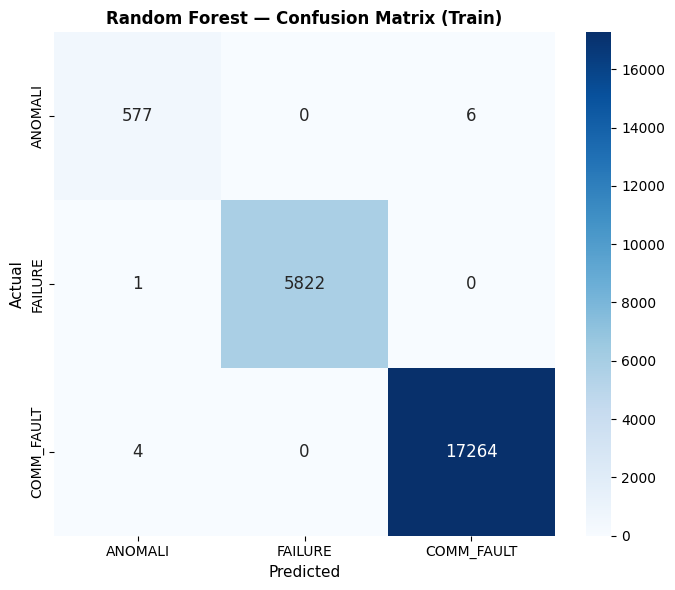

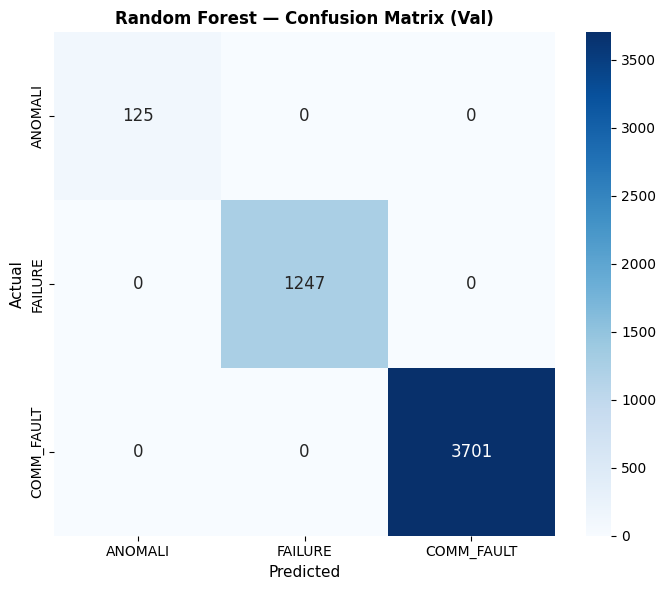

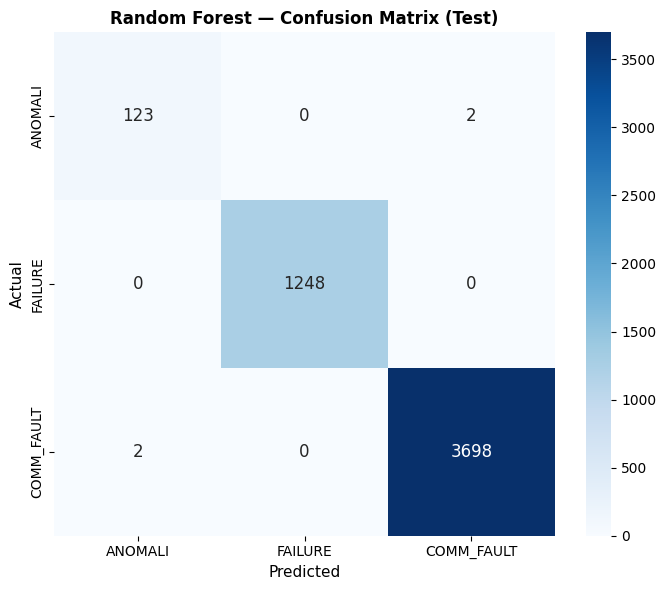

In [65]:
# ============================================================
# CELL 7: RF best-per-N + best overall + final eval + CM
# ============================================================
def best_per_n_s2(df_tuning):
    df = df_tuning.copy().sort_values(['n_features', 'accuracy'], ascending=[True, False])
    return df.groupby('n_features', as_index=False).head(1).reset_index(drop=True)

best_rf_per_n = best_per_n_s2(df_rf_s2)

print("=" * 90)
print(" BEST CONFIG PER N — Random Forest (sorted by ACCURACY)")
print("=" * 90)
RF_PARAM_COLS = ['n_estimators', 'max_depth', 'min_samples_split', 'min_samples_leaf']
for _, row in best_rf_per_n.iterrows():
    n = int(row['n_features'])
    params_str = ", ".join(f"{c}={row[c]}" for c in RF_PARAM_COLS)
    print(f"N = {n:>3}  |  {params_str}  |  "
          f"recall={row['recall_macro']:.4f}, precision={row['precision_macro']:.4f}, "
          f"accuracy={row['accuracy']:.4f}, f1={row['F1_macro']:.4f}")

# Best overall: accuracy desc, lalu n_features asc (parsimony, tie-break deterministik)
best_rf_s2 = best_rf_per_n.sort_values(['accuracy', 'n_features'], ascending=[False, True]).iloc[0]
print(f"\n>>> BEST OVERALL RF: N = {int(best_rf_s2['n_features'])}, "
      f"accuracy={best_rf_s2['accuracy']:.4f} "
      f"(precision={best_rf_s2['precision_macro']:.4f}, recall={best_rf_s2['recall_macro']:.4f}, "
      f"f1_macro={best_rf_s2['F1_macro']:.4f})")

# Train final RF
top_feat_rf_s2 = importance_rf_s2.head(int(best_rf_s2['n_features']))['feature'].tolist()
rf_final = RandomForestClassifier(
    n_estimators=int(best_rf_s2['n_estimators']),
    max_depth=int(best_rf_s2['max_depth']),
    min_samples_split=int(best_rf_s2['min_samples_split']),
    min_samples_leaf=int(best_rf_s2['min_samples_leaf']),
    random_state=RANDOM_STATE, n_jobs=-1
)
rf_final.fit(X_train_s2_scaled[top_feat_rf_s2], y_train_s2)
preds_rf = {
    'train': rf_final.predict(X_train_s2_scaled[top_feat_rf_s2]),
    'val':   rf_final.predict(X_val_s2_scaled[top_feat_rf_s2]),
    'test':  rf_final.predict(X_test_s2_scaled[top_feat_rf_s2]),
}

summary_rf = []
print("\n" + "=" * 70)
print(" Random Forest — Train/Val/Test")
print("=" * 70)
print(f"Best config: n_features={int(best_rf_s2['n_features'])}, top={top_feat_rf_s2}")
for split_name, y_pred in preds_rf.items():
    y_true = y_splits_s2[split_name]
    acc = accuracy_score(y_true, y_pred)
    prec_macro = precision_score(y_true, y_pred, average='macro', zero_division=0)
    rec_macro = recall_score(y_true, y_pred, average='macro', zero_division=0)
    f1m = f1_score(y_true, y_pred, average='macro', zero_division=0)
    f1w = f1_score(y_true, y_pred, average='weighted', zero_division=0)
    f1pc = f1_score(y_true, y_pred, average=None, zero_division=0, labels=[0, 1, 2])
    print(f"\n--- {split_name.upper()} ---")
    print(f"Accuracy : {acc:.4f}\nPrecision: {prec_macro:.4f}\nRecall   : {rec_macro:.4f}\nF1-score : {f1m:.4f}")
    print(f"F1 per kelas: ANOMALI={f1pc[0]:.4f}, FAILURE={f1pc[1]:.4f}, COMM={f1pc[2]:.4f}")
    print(classification_report(y_true, y_pred, target_names=LABELS_S2, zero_division=0, digits=4))
    summary_rf.append({
        'model': 'Random Forest', 'split': split_name,
        'accuracy': round(acc, 4), 'precision_macro': round(prec_macro, 4),
        'recall_macro': round(rec_macro, 4), 'F1_macro': round(f1m, 4),
        'F1_weighted': round(f1w, 4),
        'F1_ANOMALI': round(f1pc[0], 4), 'F1_FAILURE': round(f1pc[1], 4),
        'F1_COMM_FAULT': round(f1pc[2], 4),
    })

print("\n=== Confusion Matrix Random Forest ===")
for split_name in ['train', 'val', 'test']:
    plot_cm_separate(y_splits_s2[split_name], preds_rf[split_name], LABELS_S2,
                     split_name, 'Random Forest', STAGE2_DIR, 'rf')

In [66]:
# ============================================================
# CELL 8: TUNING XGBOOST (feature selection pakai RF importance)
# ============================================================
print("--- Tuning XGBoost ---")
XGB_GRID = {
    'n_estimators':  [50, 100],
    'max_depth':     [2, 3, 4],
    'learning_rate': [0.01, 0.05],
}
print(f"XGBoost configs per N: {len(list(ParameterGrid(XGB_GRID)))}")

results_xgb = []
for n_feat in N_VALUES_S2:
    print(f"\nN = {n_feat}")
    top_features = importance_rf_s2.head(n_feat)['feature'].tolist()
    X_tr = X_train_s2_scaled[top_features]
    X_va = X_val_s2_scaled[top_features]
    for params in ParameterGrid(XGB_GRID):
        xgb = XGBClassifier(**params, objective='multi:softprob', num_class=3,
                            random_state=RANDOM_STATE, n_jobs=-1, eval_metric='mlogloss')
        xgb.fit(X_tr, y_train_s2)
        pred = xgb.predict(X_va)
        f1pc = f1_score(y_val_s2, pred, average=None, zero_division=0, labels=[0, 1, 2])
        acc = accuracy_score(y_val_s2, pred)
        f1m = f1_score(y_val_s2, pred, average='macro', zero_division=0)
        results_xgb.append({
            'n_features': n_feat, **params,
            'accuracy': round(acc, 4),
            'precision_macro': round(precision_score(y_val_s2, pred, average='macro', zero_division=0), 4),
            'recall_macro': round(recall_score(y_val_s2, pred, average='macro', zero_division=0), 4),
            'F1_macro': round(f1m, 4),
            'F1_weighted': round(f1_score(y_val_s2, pred, average='weighted', zero_division=0), 4),
            'F1_ANOMALI': round(f1pc[0], 4),
            'F1_FAILURE': round(f1pc[1], 4),
            'F1_COMM_FAULT': round(f1pc[2], 4),
        })
        print(f"  params={params} | Acc={acc:.4f} | F1_macro={f1m:.4f}")

df_xgb_s2 = pd.DataFrame(results_xgb)
df_xgb_s2.to_excel(os.path.join(STAGE2_DIR, "tuning_xgb.xlsx"), index=False)
print(f"\n[OK] Total XGB configs evaluated: {len(df_xgb_s2)}")

--- Tuning XGBoost ---
XGBoost configs per N: 12

N = 7
  params={'learning_rate': 0.01, 'max_depth': 2, 'n_estimators': 50} | Acc=0.9998 | F1_macro=0.9986
  params={'learning_rate': 0.01, 'max_depth': 2, 'n_estimators': 100} | Acc=0.9998 | F1_macro=0.9986
  params={'learning_rate': 0.01, 'max_depth': 3, 'n_estimators': 50} | Acc=0.9998 | F1_macro=0.9986
  params={'learning_rate': 0.01, 'max_depth': 3, 'n_estimators': 100} | Acc=1.0000 | F1_macro=1.0000
  params={'learning_rate': 0.01, 'max_depth': 4, 'n_estimators': 50} | Acc=0.9998 | F1_macro=0.9986
  params={'learning_rate': 0.01, 'max_depth': 4, 'n_estimators': 100} | Acc=1.0000 | F1_macro=1.0000
  params={'learning_rate': 0.05, 'max_depth': 2, 'n_estimators': 50} | Acc=0.9998 | F1_macro=0.9986
  params={'learning_rate': 0.05, 'max_depth': 2, 'n_estimators': 100} | Acc=1.0000 | F1_macro=1.0000
  params={'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 50} | Acc=1.0000 | F1_macro=1.0000
  params={'learning_rate': 0.05, 'max_de


 BEST CONFIG PER N — XGBoost

N = 21
Top Features: ['temp_min', 'temp_mean', 'temp_max', '1h_unique_ratio', 'temp_cv', 'consecutive_identical', 'temp_std', 'temp_range', 'delta_T_std', 'max_gap_minute', 'delta_T_abs_max', 'delta_T_per_minute_max', 'n_gaps', 'delta_T_mean', 'temp_skew', 'temp_kurt', 'temp_zscore_max', 'month_sin', 'hour_cos', 'month_cos', 'hour_sin']
Best Params: n_estimators=100, max_depth=4, learning_rate=0.05
Accuracy=1.0000 | Precision=1.0000 | Recall=1.0000 | F1_macro=1.0000

N = 7
Top Features: ['temp_min', 'temp_mean', 'temp_max', '1h_unique_ratio', 'temp_cv', 'consecutive_identical', 'temp_std']
Best Params: n_estimators=50, max_depth=4, learning_rate=0.05
Accuracy=1.0000 | Precision=1.0000 | Recall=1.0000 | F1_macro=1.0000

N = 14
Top Features: ['temp_min', 'temp_mean', 'temp_max', '1h_unique_ratio', 'temp_cv', 'consecutive_identical', 'temp_std', 'temp_range', 'delta_T_std', 'max_gap_minute', 'delta_T_abs_max', 'delta_T_per_minute_max', 'n_gaps', 'delta_T_mea

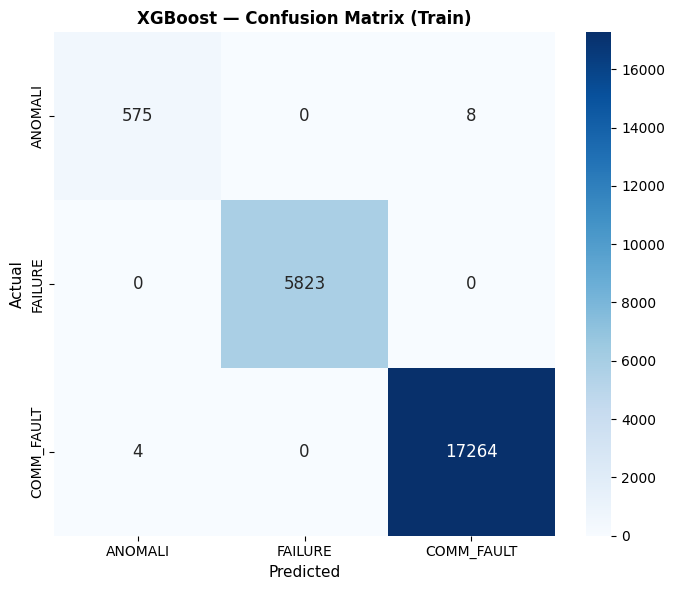

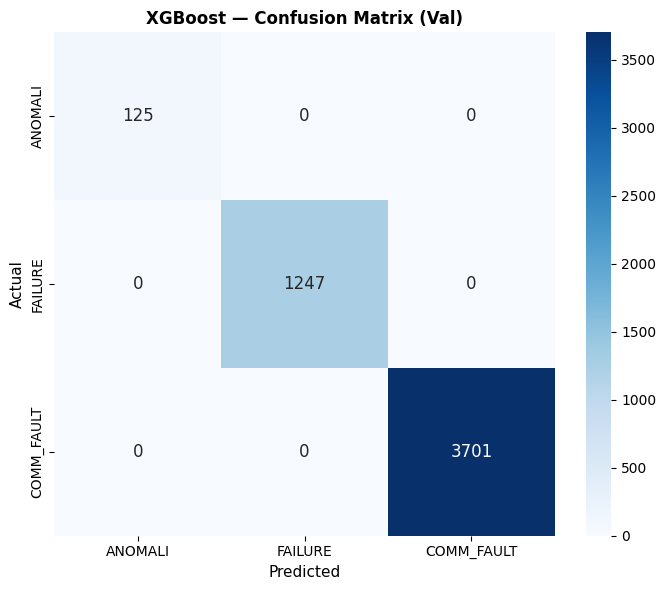

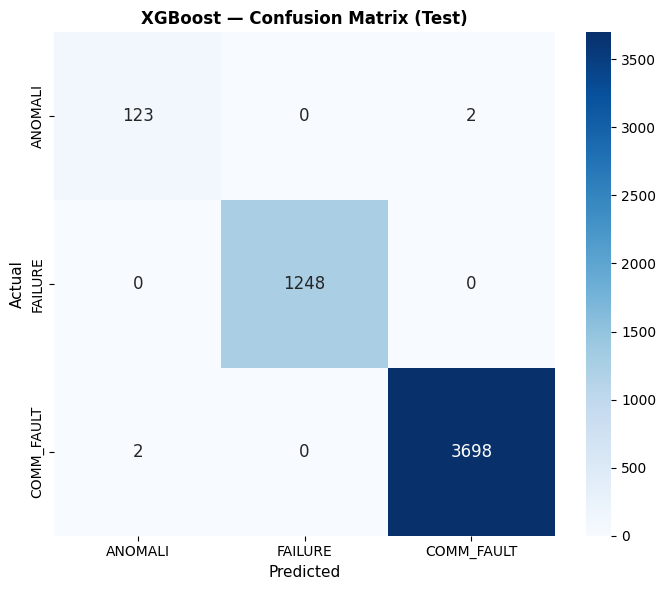

In [67]:
# ============================================================
# CELL 9: XGBoost best + final eval + CM
# ============================================================
best_xgb_per_n = (df_xgb_s2.sort_values('accuracy', ascending=False)
                  .groupby('n_features').head(1).reset_index(drop=True))

print("\n" + "=" * 90)
print(" BEST CONFIG PER N — XGBoost")
print("=" * 90)
for _, row in best_xgb_per_n.iterrows():
    n_feat = int(row['n_features'])
    top_features = importance_rf_s2.head(n_feat)['feature'].tolist()
    print(f"\nN = {n_feat}")
    print(f"Top Features: {top_features}")
    print(f"Best Params: n_estimators={int(row['n_estimators'])}, "
          f"max_depth={int(row['max_depth'])}, learning_rate={row['learning_rate']}")
    print(f"Accuracy={row['accuracy']:.4f} | Precision={row['precision_macro']:.4f} | "
          f"Recall={row['recall_macro']:.4f} | F1_macro={row['F1_macro']:.4f}")

# Best overall: accuracy desc, n_features asc (parsimony)
best_xgb_s2 = best_xgb_per_n.sort_values(['accuracy', 'n_features'], ascending=[False, True]).iloc[0]
print(f"\n>>> BEST OVERALL XGBoost")
print(f"N={int(best_xgb_s2['n_features'])} | Accuracy={best_xgb_s2['accuracy']:.4f} | "
      f"Precision={best_xgb_s2['precision_macro']:.4f} | Recall={best_xgb_s2['recall_macro']:.4f} | "
      f"F1_macro={best_xgb_s2['F1_macro']:.4f}")

# Train final XGB
top_feat_xgb_s2 = importance_rf_s2.head(int(best_xgb_s2['n_features']))['feature'].tolist()
xgb_final = XGBClassifier(
    n_estimators=int(best_xgb_s2['n_estimators']),
    max_depth=int(best_xgb_s2['max_depth']),
    learning_rate=float(best_xgb_s2['learning_rate']),
    objective='multi:softprob', num_class=3,
    random_state=RANDOM_STATE, n_jobs=-1, eval_metric='mlogloss'
)
xgb_final.fit(X_train_s2_scaled[top_feat_xgb_s2], y_train_s2)
preds_xgb = {
    'train': xgb_final.predict(X_train_s2_scaled[top_feat_xgb_s2]),
    'val':   xgb_final.predict(X_val_s2_scaled[top_feat_xgb_s2]),
    'test':  xgb_final.predict(X_test_s2_scaled[top_feat_xgb_s2]),
}

summary_xgb = []
print("\n" + "=" * 70)
print(" XGBoost — Train/Val/Test")
print("=" * 70)
print(f"Best config: n_features={int(best_xgb_s2['n_features'])}, top={top_feat_xgb_s2}")
for split_name, y_pred in preds_xgb.items():
    y_true = y_splits_s2[split_name]
    acc = accuracy_score(y_true, y_pred)
    prec_macro = precision_score(y_true, y_pred, average='macro', zero_division=0)
    rec_macro = recall_score(y_true, y_pred, average='macro', zero_division=0)
    f1m = f1_score(y_true, y_pred, average='macro', zero_division=0)
    f1w = f1_score(y_true, y_pred, average='weighted', zero_division=0)
    f1pc = f1_score(y_true, y_pred, average=None, zero_division=0, labels=[0, 1, 2])
    print(f"\n--- {split_name.upper()} ---")
    print(f"Accuracy : {acc:.4f}\nPrecision: {prec_macro:.4f}\nRecall   : {rec_macro:.4f}\nF1-score : {f1m:.4f}")
    print(f"F1 per kelas: ANOMALI={f1pc[0]:.4f}, FAILURE={f1pc[1]:.4f}, COMM={f1pc[2]:.4f}")
    print(classification_report(y_true, y_pred, target_names=LABELS_S2, zero_division=0, digits=4))
    summary_xgb.append({
        'model': 'XGBoost', 'split': split_name,
        'accuracy': round(acc, 4), 'precision_macro': round(prec_macro, 4),
        'recall_macro': round(rec_macro, 4), 'F1_macro': round(f1m, 4),
        'F1_weighted': round(f1w, 4),
        'F1_ANOMALI': round(f1pc[0], 4), 'F1_FAILURE': round(f1pc[1], 4),
        'F1_COMM_FAULT': round(f1pc[2], 4),
    })

print("\n=== Confusion Matrix XGBoost ===")
for split_name in ['train', 'val', 'test']:
    plot_cm_separate(y_splits_s2[split_name], preds_xgb[split_name], LABELS_S2,
                     split_name, 'XGBoost', STAGE2_DIR, 'xgb')

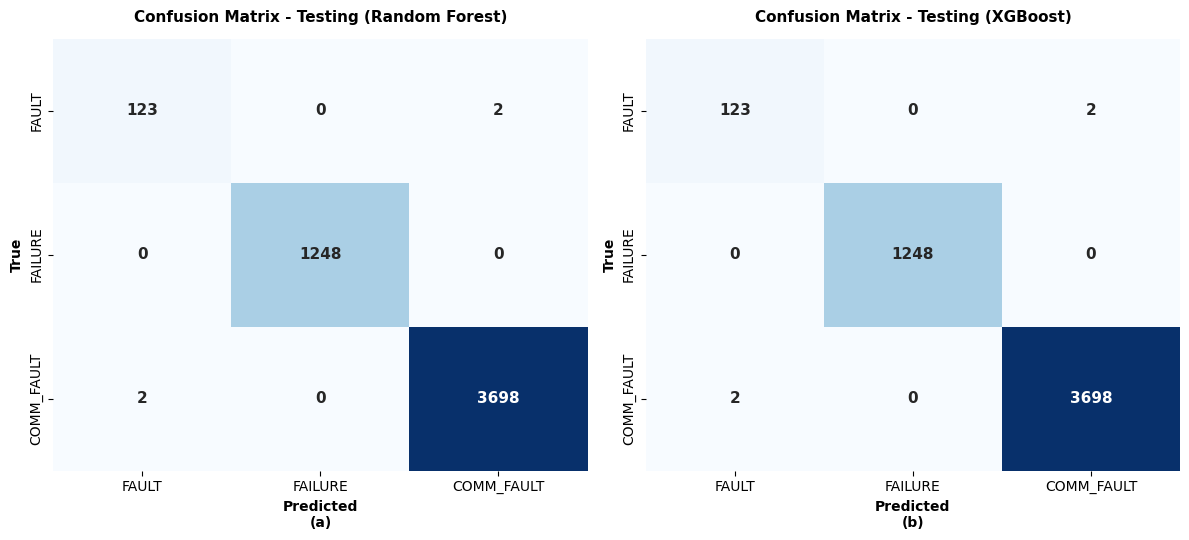

In [68]:
# ============================================================
# CONFUSION MATRIX — TESTING ONLY
# Random Forest vs XGBoost
import os
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

LABELS_CM = [
    'FAULT',
    'FAILURE',
    'COMM_FAULT'
]

# CREATE FIGURE
fig, axes = plt.subplots(1, 2, figsize=(12, 5.5))


# RANDOM FOREST
cm_rf = confusion_matrix(
    y_splits_s2['test'],
    preds_rf['test'],
    labels=list(range(len(LABELS_CM)))
)

sns.heatmap(
    cm_rf,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=LABELS_CM,
    yticklabels=LABELS_CM,
    cbar=False,
    ax=axes[0],
    annot_kws={
        'size': 11,
        'fontweight': 'bold'
    }
)

axes[0].set_title(
    'Confusion Matrix - Testing (Random Forest)',
    fontsize=11,
    fontweight='bold',
    pad=12
)

axes[0].set_ylabel(
    'True',
    fontsize=10,
    fontweight='bold'
)

axes[0].set_xlabel(
    'Predicted\n(a)',
    fontsize=10,
    fontweight='bold'
)


# XGBOOST
cm_xgb = confusion_matrix(
    y_splits_s2['test'],
    preds_xgb['test'],
    labels=list(range(len(LABELS_CM)))
)

sns.heatmap(
    cm_xgb,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=LABELS_CM,
    yticklabels=LABELS_CM,
    cbar=False,
    ax=axes[1],
    annot_kws={
        'size': 11,
        'fontweight': 'bold'
    }
)

axes[1].set_title(
    'Confusion Matrix - Testing (XGBoost)',
    fontsize=11,
    fontweight='bold',
    pad=12
)

axes[1].set_ylabel(
    'True',
    fontsize=10,
    fontweight='bold'
)

axes[1].set_xlabel(
    'Predicted\n(b)',
    fontsize=10,
    fontweight='bold'
)

# FINAL LAYOUT
plt.tight_layout()

plt.show()
